#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
app=pd.read_csv('/content/application_data.csv')
prev_app=pd.read_csv('/content/previous_application.csv')

In [ ]:
Region= app.groupby('TARGET')['REGION_RATING_CLIENT'].count()
print(Region)

TARGET
0    282686
1     24825
Name: REGION_RATING_CLIENT, dtype: int64


In [ ]:
Region2=app.groupby('REGION_RATING_CLIENT')['TARGET'].count()
print(Region2)

REGION_RATING_CLIENT
1     32197
2    226984
3     48330
Name: TARGET, dtype: int64


In [ ]:
Region3= app.groupby('TARGET')['REGION_RATING_CLIENT']
print(Region3.value_counts())

TARGET  REGION_RATING_CLIENT
0       2                       209077
        3                        42964
        1                        30645
1       2                        17907
        3                         5366
        1                         1552
Name: count, dtype: int64


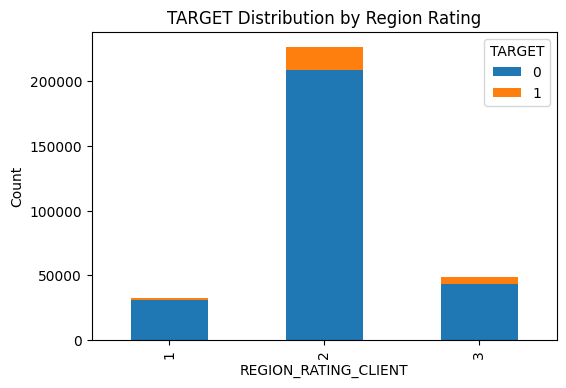

In [ ]:
region_counts = app.groupby('REGION_RATING_CLIENT')['TARGET'].value_counts().unstack()

region_counts.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("TARGET Distribution by Region Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
Client_org= app.groupby('ORGANIZATION_TYPE')['TARGET']
print(Client_org.value_counts())

ORGANIZATION_TYPE  TARGET
Advertising        0           394
                   1            35
Agriculture        0          2197
                   1           257
Bank               0          2377
                             ...  
Transport: type 4  1           501
University         0          1262
                   1            65
XNA                0         52384
                   1          2990
Name: count, Length: 116, dtype: int64


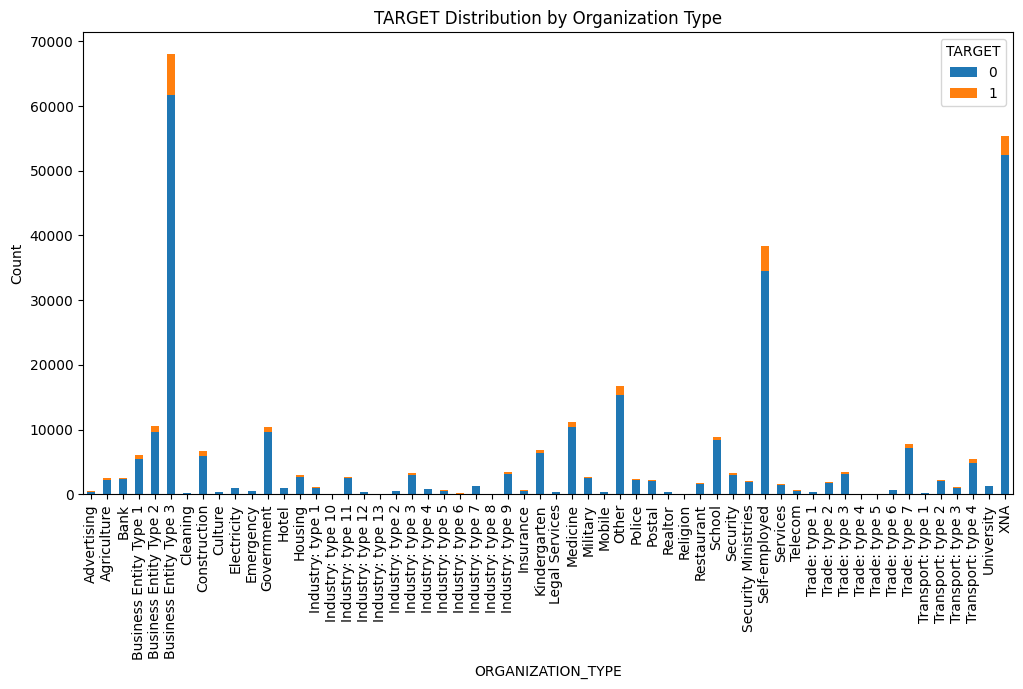

In [ ]:
org_counts = app.groupby('ORGANIZATION_TYPE')['TARGET'].value_counts().unstack()

org_counts.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("TARGET Distribution by Organization Type")
plt.ylabel("Count")
plt.show()

In [ ]:
org= app['ORGANIZATION_TYPE'].head(20)
print(org.value_counts())

ORGANIZATION_TYPE
Business Entity Type 3    3
Government                2
XNA                       2
Other                     2
Business Entity Type 2    2
School                    1
Religion                  1
Electricity               1
Medicine                  1
Self-employed             1
Transport: type 2         1
Construction              1
Housing                   1
Kindergarten              1
Name: count, dtype: int64


In [ ]:
print(app['NAME_CONTRACT_TYPE'].value_counts())

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64


In [ ]:
app.groupby(['NAME_CONTRACT_TYPE','AMT_CREDIT','AMT_GOODS_PRICE'])['TARGET'].mean()

NAME_CONTRACT_TYPE  AMT_CREDIT  AMT_GOODS_PRICE
Cash loans          45000.0     45000.0            0.052174
                    47970.0     45000.0            0.041284
                    48519.0     40500.0            0.000000
                    49455.0     45000.0            0.052632
                    49500.0     49500.0            0.000000
                                                     ...   
Revolving loans     1575000.0   1575000.0          0.000000
                    1687500.0   1687500.0          0.000000
                    1800000.0   1800000.0          0.000000
                    2025000.0   2025000.0          0.000000
                    2250000.0   2250000.0          0.000000
Name: TARGET, Length: 5824, dtype: float64

In [ ]:
app.groupby(['NAME_CONTRACT_TYPE','AMT_CREDIT','AMT_GOODS_PRICE'])['TARGET'].value_counts()

NAME_CONTRACT_TYPE  AMT_CREDIT  AMT_GOODS_PRICE  TARGET
Cash loans          45000.0     45000.0          0         218
                                                 1          12
                    47970.0     45000.0          0         209
                                                 1           9
                    48519.0     40500.0          0           1
                                                          ... 
Revolving loans     1575000.0   1575000.0        0           4
                    1687500.0   1687500.0        0           1
                    1800000.0   1800000.0        0           8
                    2025000.0   2025000.0        0           5
                    2250000.0   2250000.0        0          47
Name: count, Length: 8259, dtype: int64

In [ ]:
reachability= app.groupby('FLAG_CONT_MOBILE')['TARGET'].value_counts()
print(reachability)

FLAG_CONT_MOBILE  TARGET
0                 0            529
                  1             45
1                 0         282157
                  1          24780
Name: count, dtype: int64


In [ ]:
new_data=prev_app.groupby(['NAME_CLIENT_TYPE','AMT_CREDIT','RATE_INTEREST_PRIMARY'])['NAME_CASH_LOAN_PURPOSE']

In [ ]:
print(new_data.value_counts())

NAME_CLIENT_TYPE  AMT_CREDIT  RATE_INTEREST_PRIMARY  NAME_CASH_LOAN_PURPOSE
New               7299.0      0.196928               XAP                       1
                  12847.5     0.196900               XAP                       1
                  12865.5     0.189122               XAP                       1
                  13162.5     0.189122               XAP                       1
                  13855.5     0.191743               XAP                       1
                                                                              ..
XNA               52492.5     0.196900               XAP                       1
                  65965.5     0.189136               XAP                       1
                  88002.0     0.189136               XAP                       1
                  90112.5     0.189136               XAP                       1
                  109728.0    0.189136               XAP                       1
Name: count, Length: 2280, dtype: